# 일반 문화시설 접근성 분석 테이블 생성

문화누리 가맹점 접근성 분석과 동일한 네트워크 기준을 사용하되, 목적지를 일반 문화시설로 대체하여 격자-시설 접근 가능 pair 테이블을 생성한다.
결과는 대용량 중복을 줄이기 위해 접근성 fact table과 격자/시설 dimension table로 분리하여 저장한다.

## 분석 환경 및 경로 설정

프로젝트 루트, 기존 네트워크 산출물, 일반 문화시설 원자료, 접근성 분석 결과 저장 경로를 한 번에 정의한다.

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import shutil
import time

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
from scipy.spatial import cKDTree

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path.cwd()
for path in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (path / "analysis_table").exists() and (path / "notebooks").exists():
        PROJECT_ROOT = path
        break

ACCESS_PATH = PROJECT_ROOT / "notebooks" / "access"
OUTPUT_PATH = ACCESS_PATH / "OUTPUT" / "public_access_table"
IMAGE_PATH = ACCESS_PATH / "IMAGE" / "public_access_table"
ANALYSIS_OUTPUT = PROJECT_ROOT / "analysis_table" / "data" / "output"
GENERAL_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "policy_access_eda" / "facility_general_master.gpkg"

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
IMAGE_PATH.mkdir(parents=True, exist_ok=True)

GRID_PATH = ANALYSIS_OUTPUT / "서울시_100m_문화누리추정인구수.gpkg"
MNC_STORE_PATH = ANALYSIS_OUTPUT / "서울시_문화누리카드_가맹점_2026.gpkg"
BOUNDARY_PATH = ANALYSIS_OUTPUT / "서울시_시군구_행정동_경계.gpkg"
DONG_POP_PATH = ANALYSIS_OUTPUT / "서울시_행정동별_인구수_2024.csv"

WALK_GRAPH_PATH = ANALYSIS_OUTPUT / "도보_네트워크_graph.graphml"
WALK_NODE_PATH = ANALYSIS_OUTPUT / "도보_네트워크_nodes.gpkg"
TRANSIT_GRAPH_PATH = ANALYSIS_OUTPUT / "대중교통_네트워크_graph.graphml"
TRANSIT_NODE_PATH = ANALYSIS_OUTPUT / "대중교통_네트워크_nodes.gpkg"

GRID_WALK_NODE_PATH = ANALYSIS_OUTPUT / "격자_도보노드_연결테이블.csv"
GRID_TRANSIT_NODE_PATH = ANALYSIS_OUTPUT / "격자_대중교통노드_연결테이블.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_PATH:", OUTPUT_PATH)
print("IMAGE_PATH:", IMAGE_PATH)

PROJECT_ROOT: C:\project\oracle_mnc_project
OUTPUT_PATH: C:\project\oracle_mnc_project\notebooks\access\OUTPUT\public_access_table
IMAGE_PATH: C:\project\oracle_mnc_project\notebooks\access\IMAGE\public_access_table


## 기준 데이터 불러오기 및 사전 비교

본격적인 접근성 테이블 생성 전에 문화누리 가맹점과 일반 문화시설의 규모를 비교하고, 분석 대상 인구 총량은 일반 총 추정 인구와 문화누리대상자 추정 인구만 비교한다.

In [ ]:
grid = gpd.read_file(GRID_PATH)
mnc_store = gpd.read_file(MNC_STORE_PATH)
general_raw = gpd.read_file(GENERAL_DATA_PATH)

print("격자 테이블:", grid.shape, grid.crs)
print("문화누리 가맹점:", mnc_store.shape, mnc_store.crs)
print("일반 문화시설:", general_raw.shape, general_raw.crs)

print("\n[시설 수 비교]")
print("문화누리 가맹점 수:", len(mnc_store))
print("일반 문화시설 수:", len(general_raw))

print("\n문화누리 가맹점 중분류")
print(mnc_store["중분류"].value_counts(dropna=False))

print("\n일반 문화시설 중분류")
print(general_raw["mnc_middle_cat"].value_counts(dropna=False))

population_compare = pd.DataFrame({
    "구분": ["일반 총 추정 인구", "문화누리대상자 추정 인구"],
    "인구수": [
        grid["추정_인구수"].sum(),
        grid["문화누리대상자_추정_인구수"].sum()
    ]
})
population_compare["일반_총추정인구_대비_비율"] = (
    population_compare["인구수"] / grid["추정_인구수"].sum() * 100
)

print("\n[분석 대상 인구 총량 비교]")
display(population_compare)

## 일반 문화시설 테이블 정리

일반 문화시설 원자료의 칼럼명을 접근성 분석용 이름으로 정리하고, 행정동 경계를 이용해 시설의 시군구·행정동 정보를 보완한다.
문화누리 가맹점에는 존재하지만 일반 문화시설 원자료에는 없는 전화결제·장애인친화시설·찾아가는문화서비스 칼럼은 비교 구조 유지를 위해 결측 칼럼으로 생성한다.

In [3]:
boundary = gpd.read_file(BOUNDARY_PATH).to_crs("EPSG:5179")
general = general_raw.to_crs("EPSG:5179").copy()

general = general.rename(
    columns={
        "facility_id": "시설_ID",
        "facility_name": "시설명",
        "facility_set": "시설구분",
        "mnc_middle_cat": "중분류",
        "mnc_sub_cat": "소분류",
        "gu_nm": "시군구_시설",
    }
)

print("시군구 결측 보완 전:", general["시군구_시설"].isna().sum())

general_hjd = gpd.sjoin(
    general,
    boundary[["시군구", "행정동", "geometry"]],
    how="left",
    predicate="within"
).drop(columns="index_right", errors="ignore")

general_hjd["시군구_시설"] = general_hjd["시군구_시설"].fillna(general_hjd["시군구"])
general_hjd = general_hjd.rename(columns={"행정동": "행정동_시설"})
general_hjd = general_hjd.drop(columns="시군구", errors="ignore")

out_seoul_count = general_hjd["행정동_시설"].isna().sum()
print("서울 행정동 경계 밖 일반 문화시설:", out_seoul_count)

# 문화누리 가맹점 전처리와 동일하게 서울 경계 밖 시설은 제외한다.
general_hjd = general_hjd[general_hjd["행정동_시설"].notna()].copy()

general_hjd["대분류"] = "일반문화시설"

service_cols = ["전화결제", "장애인친화시설", "찾아가는문화서비스"]
matched_service_cols = [
    col for col in general_hjd.columns
    if any(key in col for key in ["전화", "장애", "노인", "편의", "찾아가는"])
]

print("일반 문화시설 원자료 내 편의/서비스 관련 후보 칼럼:", matched_service_cols)

for col in service_cols:
    if col not in general_hjd.columns:
        general_hjd[col] = pd.NA

general_facility = general_hjd[
    [
        "시설_ID",
        "시설명",
        "시설구분",
        "source",
        "시군구_시설",
        "행정동_시설",
        "대분류",
        "중분류",
        "소분류",
        "access_mode",
        "전화결제",
        "장애인친화시설",
        "찾아가는문화서비스",
        "geometry",
    ]
].copy()

print("최종 일반 문화시설:", general_facility.shape)
print("시설 ID 중복:", general_facility["시설_ID"].duplicated().sum())
print("결측치")
print(general_facility.isna().sum())
print("\n접근수단 분포")
print(general_facility["access_mode"].value_counts())
print("\n중분류 분포")
print(general_facility["중분류"].value_counts())
display(general_facility.head())

시군구 결측 보완 전: 16901
서울 행정동 경계 밖 일반 문화시설: 1028
일반 문화시설 원자료 내 편의/서비스 관련 후보 칼럼: []
최종 일반 문화시설: (31887, 14)
시설 ID 중복: 0
결측치
시설_ID              0
시설명                0
시설구분               0
source             0
시군구_시설             0
행정동_시설             0
대분류                0
중분류                0
소분류             2017
access_mode        0
전화결제           31887
장애인친화시설        31887
찾아가는문화서비스      31887
geometry           0
dtype: int64

접근수단 분포
access_mode
walk       21025
transit    10862
Name: count, dtype: int64

중분류 분포
중분류
체육시설     13394
미술        9048
체육용품      2457
문화체험      2280
도서        2012
공연        1352
음악         882
관광지        438
스포츠관람       24
Name: count, dtype: int64


,시설_ID,시설명,시설구분,source,시군구_시설,행정동_시설,대분류,중분류,소분류,access_mode,전화결제,장애인친화시설,찾아가는문화서비스,geometry
0,culture_performingplace_131,국립극장,general,문화예술공간 API,중구,장충동,일반문화시설,공연,NaN,transit,<NA>,<NA>,<NA>,POINT (955799.979 1950503.497)
1,culture_performingplace_54,은평문화예술회관,general,문화예술공간 API,은평구,녹번동,일반문화시설,공연,NaN,transit,<NA>,<NA>,<NA>,POINT (949494.509 1956189.029)
2,culture_performingplace_6031,640아트타워,general,문화예술공간 API,강남구,압구정동,일반문화시설,공연,NaN,transit,<NA>,<NA>,<NA>,POINT (959004.818 1947684.475)
3,culture_performingplace_2339,이화여자대학교 김영의홀,general,문화예술공간 API,서대문구,신촌동,일반문화시설,공연,NaN,transit,<NA>,<NA>,<NA>,POINT (951361.166 1951460.274)
4,culture_performingplace_960,올림아트센터(구 스튜디오76),general,문화예술공간 API,종로구,이화동,일반문화시설,공연,NaN,transit,<NA>,<NA>,<NA>,POINT (956229.67 1953480.882)


## 접근성 기준 및 수식

문화누리 접근성 분석과 동일한 비용 정의를 사용한다.

- 도보 접근비용:

  `도보_접근비용(m) = max(격자_스냅거리 - 35.35, 0) + 도보_네트워크거리 + 시설_스냅거리`

  `도보 접근 가능 = 도보_접근비용 <= 750m`

- 대중교통 접근비용:

  `시설_하차접근시간 = 시설_스냅거리 / 75`

  `대중교통_접근비용(min) = 격자_탑승접근시간 + 대중교통_네트워크시간 + 시설_하차접근시간`

  `대중교통 접근 가능 = 대중교통_접근비용 <= 20분`

격자 출발점은 100m 격자 내부의 위치 불확실성을 고려해 중심점-격자 내부 거리 범위 0~70.7m의 평균인 35.35m를 차감한다.
시설은 point 위치가 특정되어 있으므로 시설 스냅거리는 별도 보정 없이 그대로 반영한다.

In [4]:
walk_columns = ["도서", "문화체험", "음악", "영상", "체육시설", "체육용품"]
transit_columns = ["미술", "공연", "스포츠관람", "관광지"]
remove_columns = ["여행사", "교통수단", "숙박"]

walk_limit = 750
transit_time_limit = 20
walk_speed_m_per_min = 75
grid_snap_offset = (70.7 + 0) / 2

general_walk_target = general_facility[
    general_facility["중분류"].isin(walk_columns)
].copy()

general_transit_target = general_facility[
    general_facility["중분류"].isin(transit_columns)
].copy()

general_removed = general_facility[
    general_facility["중분류"].isin(remove_columns)
].copy()

print("도보 분석 대상 일반 문화시설:", len(general_walk_target))
print(general_walk_target["중분류"].value_counts())
print("\n대중교통 분석 대상 일반 문화시설:", len(general_transit_target))
print(general_transit_target["중분류"].value_counts())
print("\n제외 대상 일반 문화시설:", len(general_removed))

missing_walk_categories = sorted(set(walk_columns) - set(general_walk_target["중분류"].unique()))
print("\n일반 문화시설에서 확인되지 않은 도보 대상 중분류:", missing_walk_categories)

도보 분석 대상 일반 문화시설: 21025
중분류
체육시설    13394
체육용품     2457
문화체험     2280
도서       2012
음악        882
Name: count, dtype: int64

대중교통 분석 대상 일반 문화시설: 10862
중분류
미술       9048
공연       1352
관광지       438
스포츠관람      24
Name: count, dtype: int64

제외 대상 일반 문화시설: 0

일반 문화시설에서 확인되지 않은 도보 대상 중분류: ['영상']


## 그래프 및 격자-node 연결 테이블 불러오기

도보·대중교통 그래프와 기존 격자-node 연결 테이블을 불러온다.
격자의 최근접 node는 문화누리 접근성 분석에서 만든 결과를 그대로 사용한다.

In [5]:
def relabel_graph_nodes_to_int(graph: nx.Graph) -> nx.Graph:
    mapping = {}
    for node in graph.nodes:
        node_text = str(node)
        if node_text.lstrip("-").isdigit():
            mapping[node] = int(node_text)
    return nx.relabel_nodes(graph, mapping, copy=True)


def coerce_graph_weight(graph: nx.Graph, weight_col: str) -> nx.Graph:
    if graph.is_multigraph():
        for _, _, _, data in graph.edges(keys=True, data=True):
            data[weight_col] = float(data.get(weight_col, 0))
    else:
        for _, _, data in graph.edges(data=True):
            data[weight_col] = float(data.get(weight_col, 0))
    return graph


walk_graph = ox.load_graphml(WALK_GRAPH_PATH)
walk_graph = relabel_graph_nodes_to_int(walk_graph)
walk_graph = coerce_graph_weight(walk_graph, "length")

transit_graph = nx.read_graphml(TRANSIT_GRAPH_PATH)
transit_graph = relabel_graph_nodes_to_int(transit_graph)
transit_graph = coerce_graph_weight(transit_graph, "time_min")

walk_node = gpd.read_file(WALK_NODE_PATH).to_crs("EPSG:5179")
transit_node = gpd.read_file(TRANSIT_NODE_PATH).to_crs("EPSG:5179")

walk_node_id_col = "osmid" if "osmid" in walk_node.columns else "index"
walk_node[walk_node_id_col] = walk_node[walk_node_id_col].astype("int64")
transit_node["node_id"] = transit_node["node_id"].astype("int64")

grid_walk_node = pd.read_csv(GRID_WALK_NODE_PATH)
grid_transit_node = pd.read_csv(GRID_TRANSIT_NODE_PATH)

grid_walk_node["도보_노드ID"] = grid_walk_node["도보_노드ID"].astype("int64")
grid_transit_node["대중교통_노드ID"] = grid_transit_node["대중교통_노드ID"].astype("int64")

grid_dim = grid[
    ["GRID_CD", "시군구", "행정동", "추정_인구수", "문화누리대상자_추정_인구수"]
].rename(
    columns={
        "시군구": "시군구_격자",
        "행정동": "행정동_격자",
    }
).copy()

grid_walk_node = grid_walk_node.merge(grid_dim, on="GRID_CD", how="left")
grid_transit_node = grid_transit_node.merge(grid_dim, on="GRID_CD", how="left")

print("도보 그래프 node/edge:", walk_graph.number_of_nodes(), walk_graph.number_of_edges())
print("대중교통 그래프 node/edge:", transit_graph.number_of_nodes(), transit_graph.number_of_edges())
print("도보 node 테이블:", walk_node.shape, "node id col:", walk_node_id_col)
print("대중교통 node 테이블:", transit_node.shape)
print("격자 도보 node 결측:", grid_walk_node["도보_노드ID"].isna().sum())
print("격자 대중교통 node 결측:", grid_transit_node["대중교통_노드ID"].isna().sum())
print("격자 dimension 결측")
print(grid_dim.isna().sum())

도보 그래프 node/edge: 180285 515136
대중교통 그래프 node/edge: 28058 49451
도보 node 테이블: (180285, 9) node id col: osmid
대중교통 node 테이블: (28058, 4)
격자 도보 node 결측: 0
격자 대중교통 node 결측: 0
격자 dimension 결측
GRID_CD           0
시군구_격자            0
행정동_격자            0
추정_인구수            0
문화누리대상자_추정_인구수    0
dtype: int64


## 일반 문화시설-node snapping

일반 문화시설 point를 도보 node와 대중교통 node에 각각 최근접 연결한다.
목적지만 일반 문화시설로 바꾸고, 격자 쪽 node 연결은 기존 문화누리 접근성 분석 결과를 그대로 사용한다.

In [6]:
def attach_nearest_node(point_gdf, node_gdf, node_id_col, output_node_col, distance_col):
    node_coord = np.column_stack([node_gdf.geometry.x.to_numpy(), node_gdf.geometry.y.to_numpy()])
    point_coord = np.column_stack([point_gdf.geometry.x.to_numpy(), point_gdf.geometry.y.to_numpy()])

    tree = cKDTree(node_coord)
    distance, index = tree.query(point_coord, k=1)

    out = point_gdf.copy()
    out[output_node_col] = node_gdf.iloc[index][node_id_col].to_numpy()
    out[distance_col] = distance
    return out


general_walk_snap = attach_nearest_node(
    general_walk_target,
    walk_node,
    walk_node_id_col,
    "도보_노드ID",
    "시설_도보_스냅거리"
)
general_walk_snap["도보_노드ID"] = general_walk_snap["도보_노드ID"].astype("int64")

general_transit_snap = attach_nearest_node(
    general_transit_target,
    transit_node,
    "node_id",
    "대중교통_노드ID",
    "시설_대중교통_스냅거리"
)
general_transit_snap["대중교통_노드ID"] = general_transit_snap["대중교통_노드ID"].astype("int64")
general_transit_snap["시설_대중교통_하차접근시간"] = (
    general_transit_snap["시설_대중교통_스냅거리"] / walk_speed_m_per_min
)

print("도보 시설-node snapping 결측:", general_walk_snap["도보_노드ID"].isna().sum())
print(general_walk_snap["시설_도보_스냅거리"].describe())
print("도보 시설 스냅거리 100m 초과:", (general_walk_snap["시설_도보_스냅거리"] > 100).sum())

print("\n대중교통 시설-node snapping 결측:", general_transit_snap["대중교통_노드ID"].isna().sum())
print(general_transit_snap["시설_대중교통_스냅거리"].describe())
print("대중교통 시설 스냅거리 300m 초과:", (general_transit_snap["시설_대중교통_스냅거리"] > 300).sum())

display(
    general_walk_snap[
        ["시설_ID", "시설명", "중분류", "소분류", "시군구_시설", "시설_도보_스냅거리"]
    ].sort_values("시설_도보_스냅거리", ascending=False).head(10)
)

display(
    general_transit_snap[
        ["시설_ID", "시설명", "중분류", "소분류", "시군구_시설", "시설_대중교통_스냅거리"]
    ].sort_values("시설_대중교통_스냅거리", ascending=False).head(10)
)

도보 시설-node snapping 결측: 0
count    21025.000000
mean        32.322401
std         21.034027
min          1.236081
25%         19.036518
50%         27.353343
75%         39.162920
max        376.749115
Name: 시설_도보_스냅거리, dtype: float64
도보 시설 스냅거리 100m 초과: 299

대중교통 시설-node snapping 결측: 0
count    10862.000000
mean       106.178803
std         95.189885
min          4.424210
25%         49.940778
50%         84.605207
75%        137.301262
max       2193.337445
Name: 시설_대중교통_스냅거리, dtype: float64
대중교통 시설 스냅거리 300m 초과: 261


,시설_ID,시설명,중분류,소분류,시군구_시설,시설_도보_스냅거리
7338,sports_97DF3C130E08BE551CFF1AA6E4DB6227,삼각산 체육회 내 간이운동시설(백련사길),체육시설,간이운동장 / 간이운동장,강북구,376.749115
7337,sports_31E48C0F5D2F7F8D1AA32D11EB6025B0,백운 산악회 내 간이운동시설(백련사길),체육시설,간이운동장 / 간이운동장,강북구,316.100759
4818,sports_2E08885097DD8DA445282C233D964CBB,어린이대공원축구장,체육시설,기타시설 / 기타시설,광진구,306.511320
4906,sports_06C5676C224A70308FE2A7BFF0CD7FA4,어린이대공원아이랜드(주),체육시설,썰매장업 / 썰매장,광진구,306.511320
23076,shop_체육용품_MA010120220808391454,로뎀스포츠,체육용품,운동용품 소매업,노원구,303.119649
3601,sports_CE795AD4FF6D8958C47661118F644958,태릉선수촌 하키경기장,체육시설,하키장 / 하키장,노원구,303.119648
3567,sports_A2132C00602169450DE84DF2AAEDE0BE,태릉선수촌 승리관,체육시설,체육관 / 구기체육관,노원구,303.119648
8528,sports_B51ACE00A6F70FFB3C14AA1376C50E61,미닛스크린골프,체육시설,가상체험 체육시설업 / 골프,도봉구,288.402937
9148,sports_DB1EF100342A6CE639EA46D47FAFCE20,리케어짐,체육시설,체력단련장업 / 체력단련장,도봉구,288.402937
5783,sports_2127C37056AD128C3844DFCBBE052E12,곰돌이어린이공원,체육시설,간이운동장 / 간이운동장,노원구,248.400903


,시설_ID,시설명,중분류,소분류,시군구_시설,시설_대중교통_스냅거리
16735,tourism_346995,원통사(서울),관광지,역사관광지 / 사찰,도봉구,2193.337445
16655,tourism_482112,천축사(서울),관광지,역사관광지 / 사찰,도봉구,2154.420759
16464,tourism_126480,관악산,관광지,자연관광지 / 산,관악구,2117.640489
16728,tourism_2783363,북한산 백운대(우이동),관광지,자연관광지 / 산,강북구,1979.111156
16606,tourism_126502,도선사(서울),관광지,역사관광지 / 사찰,강북구,1933.840171
16818,tourism_2779550,관음사국기봉,관광지,자연관광지 / 산,관악구,1791.229484
16730,tourism_126505,승가사(서울),관광지,역사관광지 / 사찰,종로구,1511.587882
16530,tourism_298341,내원사(서울),관광지,역사관광지 / 사찰,성북구,1507.690449
16736,tourism_1955511,도봉서원(서울),관광지,역사관광지 / 유적지/사적지,도봉구,1309.639583
16626,tourism_298109,금선사(서울),관광지,역사관광지 / 사찰,종로구,1274.461833


## dimension table 저장

대용량 pair 테이블에서 반복되는 격자 속성과 시설 속성은 별도 dimension table로 저장한다.
fact table은 `GRID_CD`, `시설_ID`, `접근수단`, `접근비용`을 중심으로 구성하고, 필요할 때 dimension table과 결합한다.

In [7]:
facility_dim = general_facility[
    [
        "시설_ID",
        "시설명",
        "시설구분",
        "source",
        "시군구_시설",
        "행정동_시설",
        "대분류",
        "중분류",
        "소분류",
        "access_mode",
        "전화결제",
        "장애인친화시설",
        "찾아가는문화서비스",
        "geometry",
    ]
].copy()

grid_dim.to_csv(
    OUTPUT_PATH / "일반문화시설_격자_dimension.csv",
    index=False,
    encoding="utf-8-sig"
)

facility_dim.drop(columns="geometry").to_csv(
    OUTPUT_PATH / "일반문화시설_시설_dimension.csv",
    index=False,
    encoding="utf-8-sig"
)

facility_dim.to_file(
    OUTPUT_PATH / "일반문화시설_시설_dimension.gpkg",
    driver="GPKG"
)

general_walk_snap[
    ["시설_ID", "도보_노드ID", "시설_도보_스냅거리"]
].to_csv(
    OUTPUT_PATH / "일반문화시설_도보노드_연결테이블.csv",
    index=False,
    encoding="utf-8-sig"
)

general_transit_snap[
    ["시설_ID", "대중교통_노드ID", "시설_대중교통_스냅거리", "시설_대중교통_하차접근시간"]
].to_csv(
    OUTPUT_PATH / "일반문화시설_대중교통노드_연결테이블.csv",
    index=False,
    encoding="utf-8-sig"
)

print("dimension 및 시설-node 연결 테이블 저장 완료")

dimension 및 시설-node 연결 테이블 저장 완료


## 접근성 fact table 생성 함수

결과 pair가 클 수 있으므로 메모리에 전체 결과를 쌓지 않고, 일정 행 수마다 Parquet partition으로 저장한다.

In [8]:
FACT_PATH = OUTPUT_PATH / "일반문화시설_격자_시설_접근성_fact.parquet"
SAMPLE_PATH = OUTPUT_PATH / "일반문화시설_접근성_통합테이블_샘플.csv"
SUMMARY_PATH = OUTPUT_PATH / "일반문화시설_접근성_생성요약.csv"

if FACT_PATH.exists():
    shutil.rmtree(FACT_PATH)
FACT_PATH.mkdir(parents=True, exist_ok=True)

fact_columns = [
    "GRID_CD",
    "시설_ID",
    "접근수단",
    "접근비용",
    "접근비용_단위",
    "중분류",
    "소분류",
]

sample_rows = []


def append_partition(rows, access_mode, category, part_counter):
    if len(rows) == 0:
        return part_counter

    part_dir = FACT_PATH / f"access_mode={access_mode}"
    part_dir.mkdir(parents=True, exist_ok=True)

    df = pd.DataFrame(rows, columns=fact_columns)
    df.to_parquet(part_dir / f"part_{part_counter:05d}.parquet", index=False)

    return part_counter + 1


def build_node_item_dict(df, node_col):
    result = defaultdict(list)
    for idx, row in df.iterrows():
        result[row[node_col]].append(idx)
    return result

## Reverse Dijkstra 기반 도보 접근 가능 pair 생성

일반 문화시설 node에서 역방향 그래프를 탐색하여, 원래 방향 기준으로 해당 시설까지 750m 이내 도달 가능한 격자를 찾는다.

In [9]:
walk_graph_reverse = walk_graph.reverse(copy=True)

walk_grid_info = grid_walk_node[
    ["GRID_CD", "도보_노드ID", "격자_스냅거리_보정"]
].copy()

walk_grid_dict = build_node_item_dict(walk_grid_info, "도보_노드ID")
walk_grid_lookup = walk_grid_info.to_dict("index")

walk_facility_dict = build_node_item_dict(general_walk_snap, "도보_노드ID")
walk_facility_lookup = general_walk_snap.to_dict("index")

min_grid_snap = walk_grid_info["격자_스냅거리_보정"].min()

walk_summary = {
    "접근수단": "도보",
    "분석대상_시설수": len(general_walk_snap),
    "분석대상_시설노드수": len(walk_facility_dict),
    "생성_pair수": 0,
    "연결_격자수": 0,
    "연결_시설수": 0,
}

connected_walk_grids = set()
connected_walk_facilities = set()
walk_category_counter = Counter()

rows = []
part_counter = 0
start_time = time.time()
flush_size = 200_000

for n, (facility_node, facility_idx_list) in enumerate(walk_facility_dict.items(), start=1):
    if facility_node not in walk_graph_reverse:
        continue

    min_facility_snap = min(
        walk_facility_lookup[idx]["시설_도보_스냅거리"]
        for idx in facility_idx_list
    )
    network_cutoff = walk_limit - min_grid_snap - min_facility_snap

    if network_cutoff <= 0:
        continue

    lengths = nx.single_source_dijkstra_path_length(
        walk_graph_reverse,
        facility_node,
        cutoff=network_cutoff,
        weight="length"
    )

    for grid_node, network_dist in lengths.items():
        grid_idx_list = walk_grid_dict.get(grid_node, [])
        if len(grid_idx_list) == 0:
            continue

        for grid_idx in grid_idx_list:
            grid_row = walk_grid_lookup[grid_idx]
            grid_snap = grid_row["격자_스냅거리_보정"]

            for facility_idx in facility_idx_list:
                facility_row = walk_facility_lookup[facility_idx]
                final_cost = (
                    grid_snap
                    + network_dist
                    + facility_row["시설_도보_스냅거리"]
                )

                if final_cost <= walk_limit:
                    rows.append([
                        grid_row["GRID_CD"],
                        facility_row["시설_ID"],
                        "도보",
                        final_cost,
                        "m",
                        facility_row["중분류"],
                        facility_row["소분류"],
                    ])
                    connected_walk_grids.add(grid_row["GRID_CD"])
                    connected_walk_facilities.add(facility_row["시설_ID"])
                    walk_category_counter[facility_row["중분류"]] += 1

                    if len(sample_rows) < 50_000:
                        sample_rows.append(rows[-1])

        if len(rows) >= flush_size:
            category = rows[0][5] if len(set(row[5] for row in rows)) == 1 else "mixed"
            part_counter = append_partition(rows, "도보", category, part_counter)
            walk_summary["생성_pair수"] += len(rows)
            rows = []

    if n % 500 == 0:
        elapsed_min = (time.time() - start_time) / 60
        print(f"도보 {n:,} / {len(walk_facility_dict):,}개 시설 node 처리 완료 | {elapsed_min:.1f}분")

if len(rows) > 0:
    category = rows[0][5] if len(set(row[5] for row in rows)) == 1 else "mixed"
    part_counter = append_partition(rows, "도보", category, part_counter)
    walk_summary["생성_pair수"] += len(rows)

walk_summary["연결_격자수"] = len(connected_walk_grids)
walk_summary["연결_시설수"] = len(connected_walk_facilities)

print("도보 접근 가능 pair 수:", walk_summary["생성_pair수"])
print("도보 연결 격자 수:", walk_summary["연결_격자수"])
print("도보 연결 시설 수:", walk_summary["연결_시설수"])
print("도보 중분류별 pair 수")
print(pd.Series(walk_category_counter).sort_values(ascending=False))

도보 500 / 13,537개 시설 node 처리 완료 | 0.0분


도보 1,000 / 13,537개 시설 node 처리 완료 | 0.0분


도보 1,500 / 13,537개 시설 node 처리 완료 | 0.1분


도보 2,000 / 13,537개 시설 node 처리 완료 | 0.1분


도보 2,500 / 13,537개 시설 node 처리 완료 | 0.2분


...

도보 12,000 / 13,537개 시설 node 처리 완료 | 0.8분


도보 12,500 / 13,537개 시설 node 처리 완료 | 0.9분


도보 13,000 / 13,537개 시설 node 처리 완료 | 0.9분


도보 13,500 / 13,537개 시설 node 처리 완료 | 1.0분


도보 접근 가능 pair 수: 1742551
도보 연결 격자 수: 47450
도보 연결 시설 수: 21019
도보 중분류별 pair 수
체육시설    1103299
체육용품     204328
문화체험     193098
도서       164865
음악        76961
dtype: int64


## Reverse Dijkstra 기반 대중교통 접근 가능 pair 생성

대중교통은 방향성이 있는 그래프이므로, 시설 node에서 역방향 그래프를 탐색해 원래 방향 기준으로 시설까지 20분 이내 도달 가능한 격자를 찾는다.

In [10]:
transit_graph_reverse = transit_graph.reverse(copy=True)

transit_grid_info = grid_transit_node[
    ["GRID_CD", "대중교통_노드ID", "대중교통_탑승접근시간"]
].copy()

transit_grid_dict = build_node_item_dict(transit_grid_info, "대중교통_노드ID")
transit_grid_lookup = transit_grid_info.to_dict("index")

transit_facility_dict = build_node_item_dict(general_transit_snap, "대중교통_노드ID")
transit_facility_lookup = general_transit_snap.to_dict("index")

min_grid_access_time = transit_grid_info["대중교통_탑승접근시간"].min()

transit_summary = {
    "접근수단": "대중교통",
    "분석대상_시설수": len(general_transit_snap),
    "분석대상_시설노드수": len(transit_facility_dict),
    "생성_pair수": 0,
    "연결_격자수": 0,
    "연결_시설수": 0,
}

connected_transit_grids = set()
connected_transit_facilities = set()
transit_category_counter = Counter()

rows = []
part_counter = 0
start_time = time.time()
flush_size = 200_000

for n, (facility_node, facility_idx_list) in enumerate(transit_facility_dict.items(), start=1):
    if facility_node not in transit_graph_reverse:
        continue

    min_facility_access_time = min(
        transit_facility_lookup[idx]["시설_대중교통_하차접근시간"]
        for idx in facility_idx_list
    )
    network_cutoff = transit_time_limit - min_grid_access_time - min_facility_access_time

    if network_cutoff <= 0:
        continue

    lengths = nx.single_source_dijkstra_path_length(
        transit_graph_reverse,
        facility_node,
        cutoff=network_cutoff,
        weight="time_min"
    )

    for grid_node, network_time in lengths.items():
        grid_idx_list = transit_grid_dict.get(grid_node, [])
        if len(grid_idx_list) == 0:
            continue

        for grid_idx in grid_idx_list:
            grid_row = transit_grid_lookup[grid_idx]
            grid_access_time = grid_row["대중교통_탑승접근시간"]

            for facility_idx in facility_idx_list:
                facility_row = transit_facility_lookup[facility_idx]
                facility_access_time = facility_row["시설_대중교통_하차접근시간"]

                final_cost = (
                    grid_access_time
                    + network_time
                    + facility_access_time
                )

                if final_cost <= transit_time_limit:
                    rows.append([
                        grid_row["GRID_CD"],
                        facility_row["시설_ID"],
                        "대중교통",
                        final_cost,
                        "min",
                        facility_row["중분류"],
                        facility_row["소분류"],
                    ])
                    connected_transit_grids.add(grid_row["GRID_CD"])
                    connected_transit_facilities.add(facility_row["시설_ID"])
                    transit_category_counter[facility_row["중분류"]] += 1

                    if len(sample_rows) < 50_000:
                        sample_rows.append(rows[-1])

        if len(rows) >= flush_size:
            category = rows[0][5] if len(set(row[5] for row in rows)) == 1 else "mixed"
            part_counter = append_partition(rows, "대중교통", category, part_counter)
            transit_summary["생성_pair수"] += len(rows)
            rows = []

    if n % 100 == 0:
        elapsed_min = (time.time() - start_time) / 60
        print(f"대중교통 {n:,} / {len(transit_facility_dict):,}개 시설 node 처리 완료 | {elapsed_min:.1f}분")

if len(rows) > 0:
    category = rows[0][5] if len(set(row[5] for row in rows)) == 1 else "mixed"
    part_counter = append_partition(rows, "대중교통", category, part_counter)
    transit_summary["생성_pair수"] += len(rows)

transit_summary["연결_격자수"] = len(connected_transit_grids)
transit_summary["연결_시설수"] = len(connected_transit_facilities)

print("대중교통 접근 가능 pair 수:", transit_summary["생성_pair수"])
print("대중교통 연결 격자 수:", transit_summary["연결_격자수"])
print("대중교통 연결 시설 수:", transit_summary["연결_시설수"])
print("대중교통 중분류별 pair 수")
print(pd.Series(transit_category_counter).sort_values(ascending=False))

대중교통 100 / 5,018개 시설 node 처리 완료 | 0.9분


대중교통 200 / 5,018개 시설 node 처리 완료 | 1.6분


대중교통 300 / 5,018개 시설 node 처리 완료 | 2.2분


대중교통 400 / 5,018개 시설 node 처리 완료 | 2.8분


대중교통 500 / 5,018개 시설 node 처리 완료 | 3.3분


...

대중교통 4,700 / 5,018개 시설 node 처리 완료 | 18.4분


대중교통 4,800 / 5,018개 시설 node 처리 완료 | 18.6분


대중교통 4,900 / 5,018개 시설 node 처리 완료 | 18.8분


대중교통 5,000 / 5,018개 시설 node 처리 완료 | 19.1분


대중교통 접근 가능 pair 수: 113283748
대중교통 연결 격자 수: 57132
대중교통 연결 시설 수: 10853
대중교통 중분류별 pair 수
미술       94451595
공연       14563213
관광지       4120649
스포츠관람      148291
dtype: int64


## 접근성 fact table 검토 및 샘플 결합

생성된 fact table의 규모와 중복 여부를 확인하고, 읽기 쉬운 검토용 샘플 테이블을 생성한다.

In [11]:
summary = pd.DataFrame([walk_summary, transit_summary])
summary.to_csv(SUMMARY_PATH, index=False, encoding="utf-8-sig")

fact_sample = pd.DataFrame(sample_rows, columns=fact_columns)

facility_dim_no_geom = facility_dim.drop(columns="geometry").copy()

sample_join = (
    fact_sample
    .merge(grid_dim, on="GRID_CD", how="left")
    .merge(facility_dim_no_geom, on="시설_ID", how="left", suffixes=("", "_시설"))
)

sample_join.to_csv(SAMPLE_PATH, index=False, encoding="utf-8-sig")

print("생성 요약")
display(summary)

print("샘플 테이블 결측")
print(sample_join.isna().sum())

print("샘플 GRID_CD-시설_ID-접근수단 중복:", sample_join[["GRID_CD", "시설_ID", "접근수단"]].duplicated().sum())
display(sample_join.head())

print("fact parquet 저장 위치:", FACT_PATH)
print("검토용 샘플 저장 위치:", SAMPLE_PATH)

생성 요약


,접근수단,분석대상_시설수,분석대상_시설노드수,생성_pair수,연결_격자수,연결_시설수
0,도보,21025,13537,1742551,47450,21019
1,대중교통,10862,5018,113283748,57132,10853


샘플 테이블 결측
GRID_CD               0
시설_ID                 0
접근수단                  0
접근비용                  0
접근비용_단위               0
중분류                   0
소분류               24760
시군구_격자                0
행정동_격자                0
추정_인구수                0
문화누리대상자_추정_인구수        0
시설명                   0
시설구분                  0
source                0
시군구_시설                0
행정동_시설                0
대분류                   0
중분류_시설                0
소분류_시설            24760
access_mode           0
전화결제              50000
장애인친화시설           50000
찾아가는문화서비스         50000
dtype: int64
샘플 GRID_CD-시설_ID-접근수단 중복: 0


,GRID_CD,시설_ID,접근수단,접근비용,접근비용_단위,중분류,소분류,시군구_격자,행정동_격자,추정_인구수,...,source,시군구_시설,행정동_시설,대분류,중분류_시설,소분류_시설,access_mode,전화결제,장애인친화시설,찾아가는문화서비스
0,다사623521,culture_hall_1138,도보,120.960602,m,문화체험,NaN,동대문구,장안1동,386,...,문화예술공간 API,동대문구,장안1동,일반문화시설,문화체험,NaN,walk,<NA>,<NA>,<NA>
1,다사622521,culture_hall_1138,도보,162.058080,m,문화체험,NaN,동대문구,장안2동,469,...,문화예술공간 API,동대문구,장안1동,일반문화시설,문화체험,NaN,walk,<NA>,<NA>,<NA>
2,다사623522,culture_hall_1138,도보,184.655413,m,문화체험,NaN,동대문구,장안1동,909,...,문화예술공간 API,동대문구,장안1동,일반문화시설,문화체험,NaN,walk,<NA>,<NA>,<NA>
3,다사622520,culture_hall_1138,도보,247.039887,m,문화체험,NaN,동대문구,장안1동,213,...,문화예술공간 API,동대문구,장안1동,일반문화시설,문화체험,NaN,walk,<NA>,<NA>,<NA>
4,다사624522,culture_hall_1138,도보,259.686608,m,문화체험,NaN,동대문구,장안1동,974,...,문화예술공간 API,동대문구,장안1동,일반문화시설,문화체험,NaN,walk,<NA>,<NA>,<NA>


fact parquet 저장 위치: C:\project\oracle_mnc_project\notebooks\access\OUTPUT\public_access_table\일반문화시설_격자_시설_접근성_fact.parquet
검토용 샘플 저장 위치: C:\project\oracle_mnc_project\notebooks\access\OUTPUT\public_access_table\일반문화시설_접근성_통합테이블_샘플.csv


## 결과 시각화

시설 원자료 규모와 생성된 접근 가능 pair 규모를 중분류별로 비교해 최종 산출물의 분포를 점검한다.

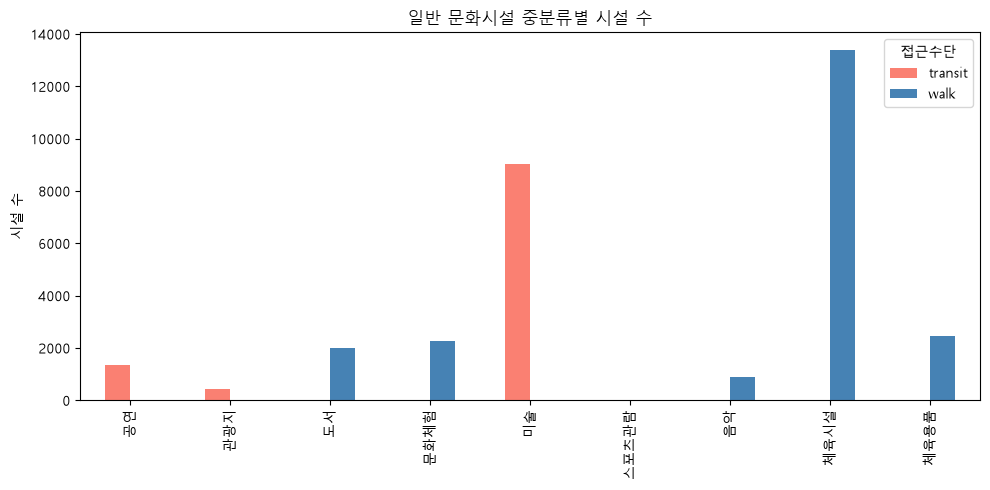

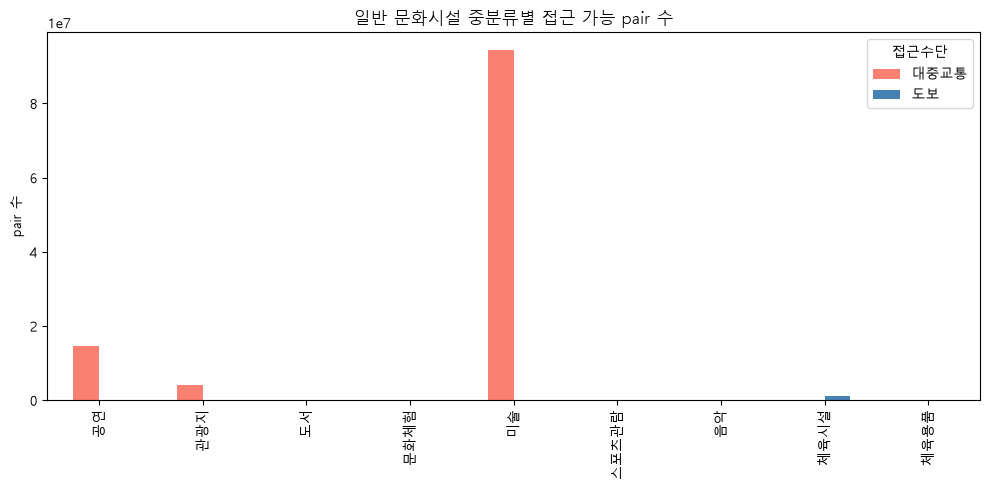

In [12]:
facility_count_plot = (
    general_facility
    .groupby(["access_mode", "중분류"])
    .size()
    .reset_index(name="시설수")
)

fig, ax = plt.subplots(figsize=(10, 5))
(
    facility_count_plot
    .pivot_table(index="중분류", columns="access_mode", values="시설수", fill_value=0)
    .sort_index()
    .plot(kind="bar", ax=ax, color=["salmon", "steelblue"])
)
ax.set_title("일반 문화시설 중분류별 시설 수")
ax.set_xlabel("")
ax.set_ylabel("시설 수")
ax.legend(title="접근수단")
plt.tight_layout()
plt.savefig(IMAGE_PATH / "일반문화시설_중분류별_시설수.png", dpi=240, bbox_inches="tight")
plt.show()

pair_count_plot = []
for mode, counter in [("도보", walk_category_counter), ("대중교통", transit_category_counter)]:
    for category, count in counter.items():
        pair_count_plot.append({"접근수단": mode, "중분류": category, "pair수": count})

pair_count_plot = pd.DataFrame(pair_count_plot)

fig, ax = plt.subplots(figsize=(10, 5))
(
    pair_count_plot
    .pivot_table(index="중분류", columns="접근수단", values="pair수", fill_value=0)
    .sort_index()
    .plot(kind="bar", ax=ax, color=["salmon", "steelblue"])
)
ax.set_title("일반 문화시설 중분류별 접근 가능 pair 수")
ax.set_xlabel("")
ax.set_ylabel("pair 수")
ax.legend(title="접근수단")
plt.tight_layout()
plt.savefig(IMAGE_PATH / "일반문화시설_중분류별_접근가능_pair수.png", dpi=240, bbox_inches="tight")
plt.show()

## 판단사항 메모

- 일반 문화시설 원자료에는 전화결제, 장애인친화시설, 찾아가는문화서비스에 대응되는 속성 칼럼이 없어 해당 칼럼은 결측으로 생성했다.
- 시설명·주소·분류를 모든 pair 행에 반복하면 대용량 중복이 커지므로, 최종 구조는 fact table과 dimension table로 분리했다.
- 문화누리 가맹점 전처리와 일관되게 서울 행정동 경계 밖 일반 문화시설은 제외했다.
- 일반 문화시설 원자료에는 `영상` 중분류에 해당하는 시설 좌표가 없어 도보 대상 중 `영상`은 생성 결과에 포함되지 않는다.